In [3]:
import pandas as pd

# LEITURA E TRATAMENTO DA BASE DE CONSTANTES

def carregar_biblioteca_antoine(Tabela_csv):
    df = pd.read_csv(Tabela_csv, sep=';')

    
    # ALTERAR NO NOME DAS COLUNAS
    df = df.rename(columns={
        'Composto': 'composto',
        'Ant(A)': 'A',
        'Ant(B)': 'B',
        'Ant(C)': 'C',
        'Max': 'Tmax',
        'Min': 'Tmin'
    })

    # MUDA VIRGULA PARA PONTO 
    colunas_numericas = ['A', 'B', 'C', 'Tmax', 'Tmin']
    for colunas in colunas_numericas:
        df[colunas] = df[colunas].astype(str).str.replace(',', '.', regex=False)
        df[colunas] = pd.to_numeric(df[colunas], errors='coerce')
           
    df = df.dropna(subset=['A', 'B', 'C']) # REMOVE LINHA EM BRANCO
    df = df.drop_duplicates(subset='composto') # REMOVE LINHA DUPLICADA
    return df

df = carregar_biblioteca_antoine('../dados/Constantes_Antoine_corrigido.csv')

biblioteca = df.set_index('composto')[['A', 'B', 'C', 'Tmax', 'Tmin']]

print(biblioteca) # EXIBIR A BIBLIOTECA 

                               A        B       C   Tmax   Tmin
composto                                                       
Argon                    15.2330   700.51   -5.84   94.0   81.0
Bromide                  15.8441  2582.32  -51.56  354.0  259.0
Nitrosyl Cloride         16.9505  2520.70  -23.46  285.0  210.0
Chloride                 15.9610  1978.32  -27.01  264.0  172.0
Silicon Tetrachloride    15.8019  2634.16  -43.15  364.0  238.0
...                          ...      ...     ...    ...    ...
n-nonadecane             16.1533  4450.44 -135.60  639.0  456.0
n-pentadecycyclopentane  16.3092  4642.01 -145.10  661.0  476.0
n-eicosane               16.4685  4680.46 -141.10  652.0  471.0
1-eiconasol              15.8233  3912.10 -203.10  679.0  492.0
n-hexadecycyclopentane   16.3553  4715.69 -152.10  674.0  488.0

[437 rows x 5 columns]


In [5]:
composto = 'Ethane' # INSIRA O NOME DO COMPOSTO PARA CONSUKLTA

A, B, C, Tmin, Tmax = biblioteca.loc[composto, ['A', 'B', 'C', 'Tmin', 'Tmax']] # RETORNA O VALOR DAS CONSTANTES

# EXIBIR O VALOR DAS CONSULTANTES DE ACORDO COM O COMPOSTO SELECIONADO
print(f"Constantes de Antoine - {composto}")
print(f"A = {A:.4f}")
print(f"B = {B:.4f}")
print(f"C = {C:.4f}")
print(f"Tmin = {Tmin:.1f}")
print(f"Tmax = {Tmax:.1f}")

Constantes de Antoine - Ethane
A = 15.6637
B = 1511.4400
C = -17.1600
Tmin = 130.0
Tmax = 199.0


In [15]:
import numpy as np

composto = 'Argon'  # ESCOLHA O COMPOSTO

def P_sat(composto, T, biblioteca): # CALCULAR A PRESSÃO DE SATURAÇÃO (mmHg)
    dados = biblioteca.loc[composto]
    A, B, C = dados['A'], dados['B'], dados['C']
    return np.exp(A - B / (T + C))

P = P_sat(composto, 120, biblioteca)
P_kPa = P /750.1 # CONVERSÃO PARA BAR
print(f"{composto}: {P_kPa:.2f} Bar") # EXIBIR A PRESSÃO CALCULADO

Argon: 11.90 Bar


In [8]:
from IPython.display import display, Math

display(Math(rf"\ln P_{{Sat}} = {A} - \frac{{{B}}}{{T+{C}}}"))


<IPython.core.display.Math object>

a2)- faça um código que solicite a maior e menor temperatura e grafique P vs T, coloque lendas, nomes rótulos ,etc


Faixa válida: 81.0 até 94.0 °C


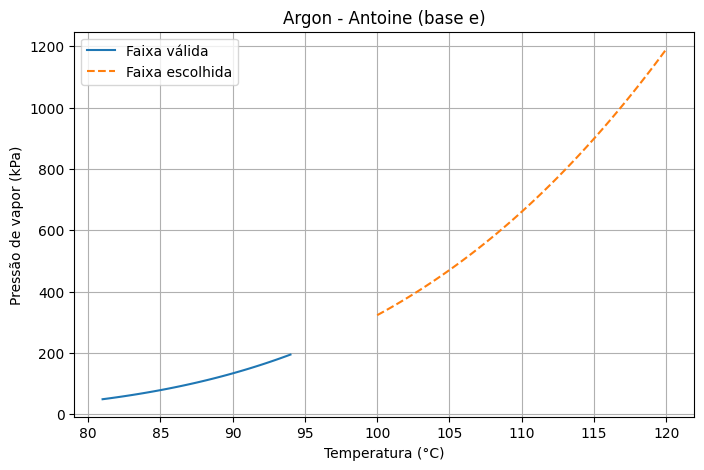

In [9]:
import numpy as np
import matplotlib.pyplot as plt

def pressao_vapor(T, composto, biblioteca):
    A, B, C = biblioteca.loc[composto, ['A', 'B', 'C']]
   # A_ln = A * np.log(10)
   # B_ln = B * np.log(10)
   # cálculo usando Ln
    return np.exp(A - B / (T + C))

if composto not in biblioteca.index:
    print("Defina primeiro um composto válido no bloco 1.")
else:
    
    Tmin_tab = biblioteca.loc[composto, "Tmin"]
    Tmax_tab = biblioteca.loc[composto, "Tmax"]

    print(f"Faixa válida: {Tmin_tab} até {Tmax_tab} °C")

    Tmin_input = float(input("Digite a temperatura mínima desejada (°C): "))
    Tmax_input = float(input("Digite a temperatura máxima desejada (°C): "))


    T_tab = np.linspace(Tmin_tab, Tmax_tab, 100)
    P_tab = pressao_vapor(T_tab, composto, biblioteca) * 0.133322

    T_user = np.linspace(Tmin_input, Tmax_input, 100)
    P_user = pressao_vapor(T_user, composto, biblioteca) * 0.133322

    plt.figure(figsize=(8, 5))
    plt.plot(T_tab, P_tab, label="Faixa válida")
    plt.plot(T_user, P_user, linestyle='--', label="Faixa escolhida")

    plt.xlabel("Temperatura (°C)")
    plt.ylabel("Pressão de vapor (kPa)")
    plt.title(f"{composto} - Antoine (base e)")
    plt.legend()
    plt.grid(True)
    plt.show()

a3)- mostre seu código comparando graficamente [matplotlib] os seguintes  compostos, discuta suas observações.

In [10]:
def carregar_base(csv_path="Constantes_Antoine_corrigido.csv"):
    df = pd.read_csv(csv_path, sep=";")
    df = df.rename(columns={
        "Composto": "composto",
        "Formula": "formula",
        "Ant(A)": "A",
        "Ant(B)": "B",
        "Ant(C)": "C",
        "Max": "Tmax",
        "Min": "Tmin",
    })

    for col in ["A", "B", "C", "Tmax", "Tmin"]:
        df[col] = pd.to_numeric(df[col].astype(str).str.replace(",", ".", regex=False), errors="coerce")

    df = df.dropna(subset=["A", "B", "C", "Tmin", "Tmax"])
    df["formula"] = df["formula"].astype(str).str.strip()
    df["composto"] = df["composto"].astype(str).str.strip()
    return df

def antoine_ln_mmHg(T_K, A, B, C):
    return np.exp(A - B / (T_K + C))

def resolver_composto(df, item):
    key = item.strip().upper()
    preferencia_formula = {"C3H6": "Propylene", "C8H10": "p-xylene", "CO2": "Carbon dioxide"}

    if key == "CO":
        m = df[df["composto"].str.lower() == "carbon monoxide"]
        if len(m): return m.iloc[0], "CO (mapeado para Carbon Monoxide; fórmula na base está como CO2)"
        return None, "CO (não encontrado)"

    if key == "H2SO4":
        m = df[df["composto"].str.lower().str.contains("sulfuric", na=False)]
        if len(m): return m.iloc[0], "H2SO4"
        return None, "H2SO4 (não encontrado na base)"

    m = df[df["formula"].str.upper() == key]
    if len(m):
        pref = preferencia_formula.get(key)
        if pref:
            p = m[m["composto"].str.lower() == pref.lower()]
            if len(p): return p.iloc[0], pref
        if key == "C8H10":
            x = m[m["composto"].str.lower().str.contains("xylene", na=False)]
            if len(x): return x.iloc[0], x.iloc[0]["composto"]
        return m.iloc[0], m.iloc[0]["composto"]

    m = df[df["composto"].str.lower() == item.strip().lower()]
    if len(m): return m.iloc[0], m.iloc[0]["composto"]

    m = df[df["composto"].str.lower().str.contains(item.strip().lower(), na=False)]
    if len(m): return m.iloc[0], m.iloc[0]["composto"]

    return None, f"{item} (não encontrado)"

def plotar_grupo(ax, df, titulo, itens, T_C_min=None, T_C_max=None):
    if T_C_min is None: T_C_min = -150.0
    if T_C_max is None: T_C_max = 450.0

    T_C = np.linspace(T_C_min, T_C_max, 500)
    T_K = T_C + 273.15 # CONVERSÃO PARA KELVIN
    observacoes = []
    plotted_any = False

    for item in itens:
        row, label = resolver_composto(df, item)
        if row is None:
            observacoes.append(f"- {label}")
            continue

        A, B, C = float(row["A"]), float(row["B"]), float(row["C"])
        Tmin_K, Tmax_K = float(row["Tmin"]), float(row["Tmax"])
        Tmin_C, Tmax_C = Tmin_K - 273.15, Tmax_K - 273.15

        P_mmHg = antoine_ln_mmHg(T_K, A, B, C)
        P_bar = P_mmHg * 0.00133322
        valido = (T_K >= Tmin_K) & (T_K <= Tmax_K)

        if np.any(valido):
            ax.plot(T_C[valido], P_bar[valido], lw=2, label=f"{label}")
            plotted_any = True
        if np.any(~valido):
            ax.plot(T_C[~valido], P_bar[~valido], lw=1.2, ls="--", alpha=0.45)

        observacoes.append(f"- {label}: faixa válida {Tmin_C:.1f} a {Tmax_C:.1f} K")

    ax.set_title(titulo)
    ax.set_xlabel("Temperatura (K)")
    ax.set_ylabel("Pressão de vapor (bar)")
    ax.set_yscale("log")
    ax.grid(True, which="both", alpha=0.25)

    if plotted_any:
        ax.legend(fontsize=8, loc="best")
    else:
        ax.text(0.03, 0.95, "Sem dados na faixa válida\n(apenas extrapolação)",
                transform=ax.transAxes, va="top", fontsize=8,
                bbox={"facecolor": "white", "alpha": 0.75, "edgecolor": "none"})

    return observacoes


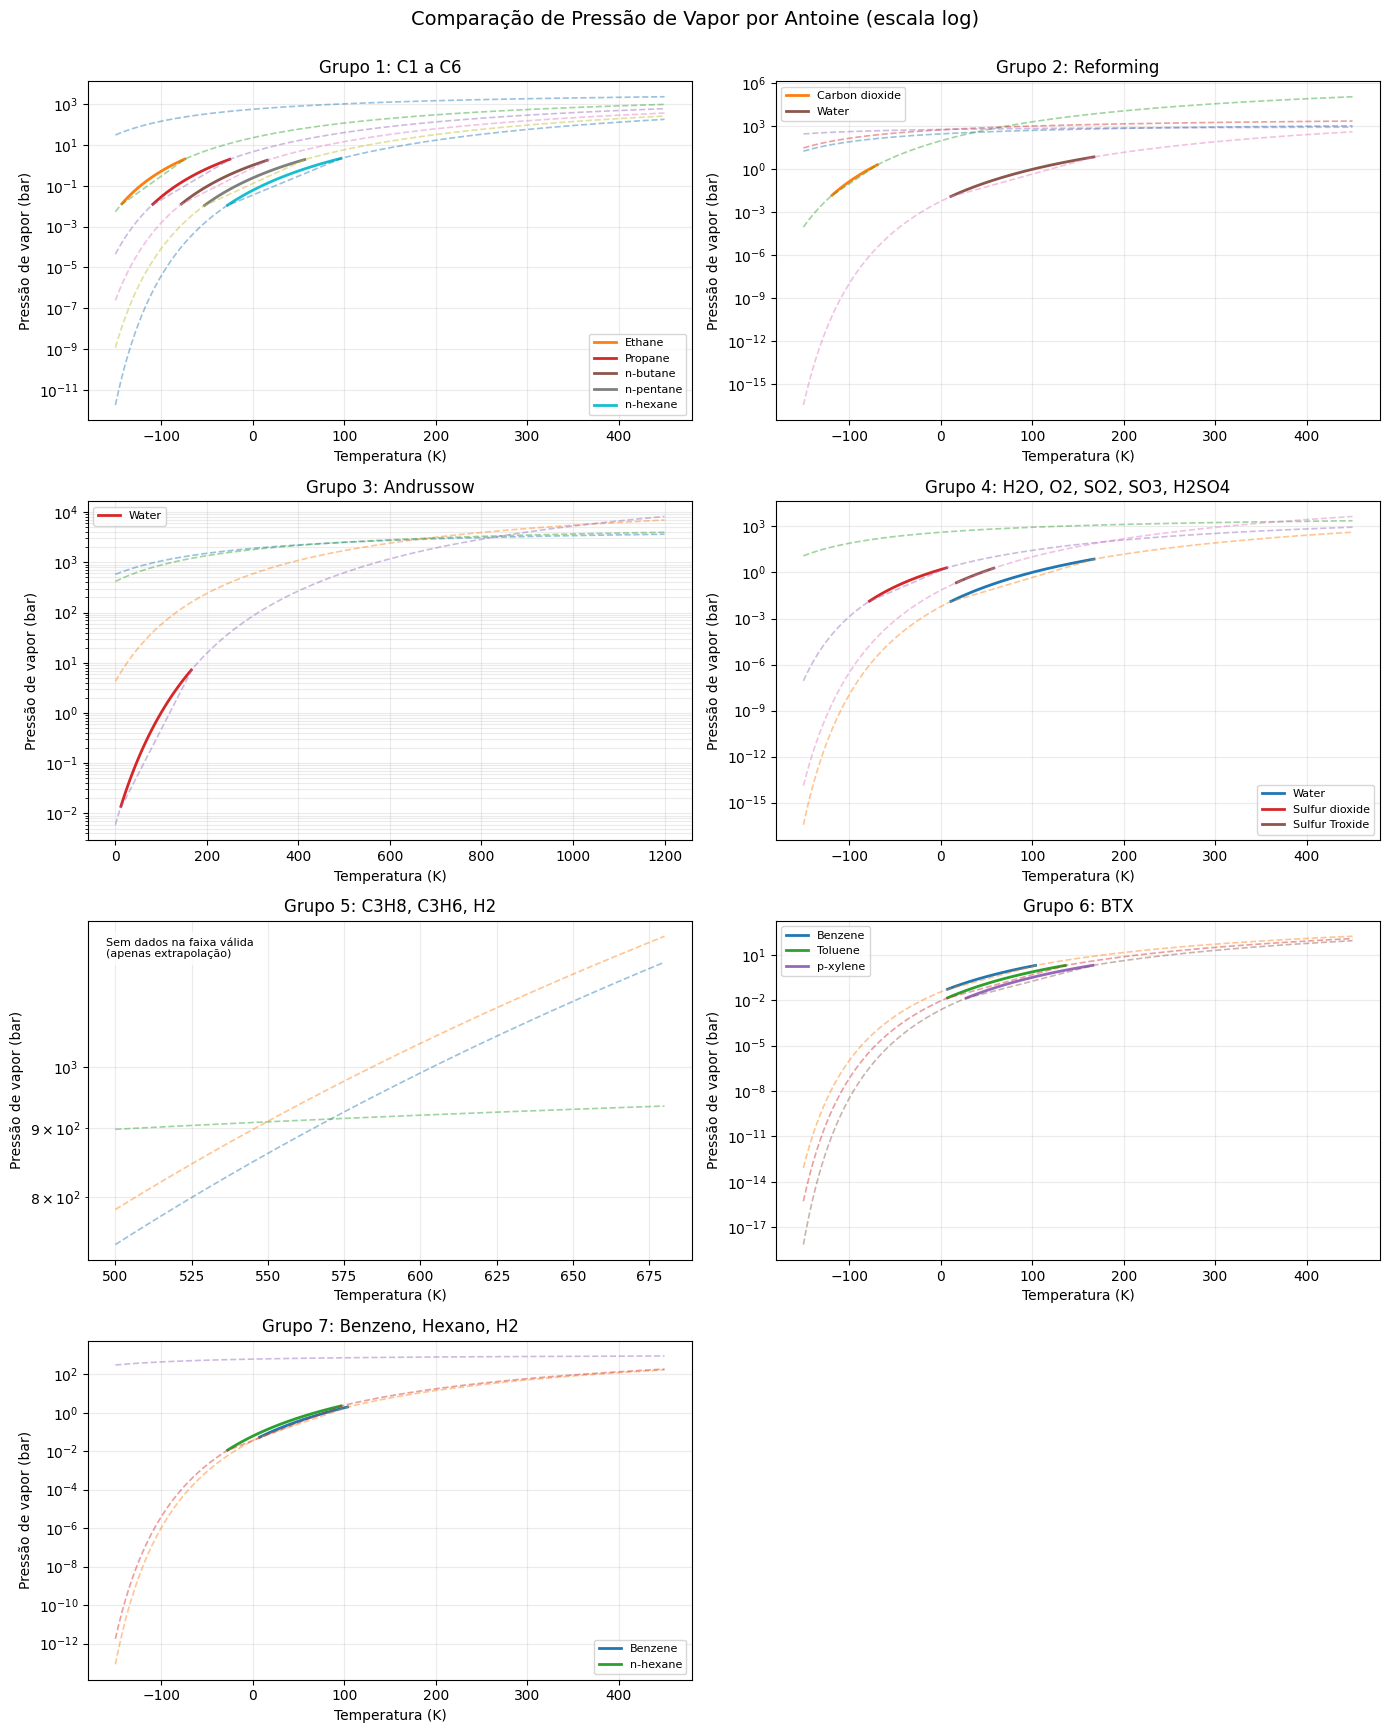

Resumo de faixas de temperatura:

Grupo 1: C1 a C6
- Methane: faixa válida -180.1 a -153.1 K
- Ethane: faixa válida -143.1 a -74.1 K
- Propane: faixa válida -109.1 a -24.1 K
- n-butane: faixa válida -78.1 a 16.9 K
- n-pentane: faixa válida -53.1 a 56.9 K
- n-hexane: faixa válida -28.1 a 96.9 K

Grupo 2: Reforming
- CO (mapeado para Carbon Monoxide; fórmula na base está como CO2): faixa válida -210.1 a -165.1 K
- Carbon dioxide: faixa válida -119.1 a -69.1 K
- Methane: faixa válida -180.1 a -153.1 K
- Hydrogen: faixa válida -259.1 a -248.1 K
- Water: faixa válida 10.9 a 167.9 K

Grupo 3: Andrussow
- Methane: faixa válida -180.1 a -153.1 K
- Ammonia: faixa válida -94.1 a -12.1 K
- Oxygen: faixa válida -210.1 a -173.1 K
- HCN (não encontrado)
- Water: faixa válida 10.9 a 167.9 K

Grupo 4: H2O, O2, SO2, SO3, H2SO4
- Water: faixa válida 10.9 a 167.9 K
- Oxygen: faixa válida -210.1 a -173.1 K
- Sulfur dioxide: faixa válida -78.1 a 6.9 K
- Sulfur Troxide: faixa válida 16.9 a 58.9 K
- H2SO4 (n

In [11]:
df = carregar_base("Constantes_Antoine_corrigido.csv")

# GRUPOS DISPONÍVEIS NO EXERCÍCIO
grupos = [
    ("Grupo 1: C1 a C6", ["CH4", "C2H6", "C3H8", "C4H10", "C5H12", "C6H14"], None, None),
    ("Grupo 2: Reforming", ["CO", "CO2", "CH4", "H2", "H2O"], None, None),
    ("Grupo 3: Andrussow", ["CH4", "NH3", "O2", "HCN", "H2O"], 0, 1200),
    ("Grupo 4: H2O, O2, SO2, SO3, H2SO4", ["H2O", "O2", "SO2", "SO3", "H2SO4"], None, None),
    ("Grupo 5: C3H8, C3H6, H2", ["C3H8", "C3H6", "H2"], 500, 680),
    ("Grupo 6: BTX", ["C6H6", "C7H8", "C8H10"], None, None),
    ("Grupo 7: Benzeno, Hexano, H2", ["C6H6", "C6H14", "H2"], None, None),
]

fig, axes = plt.subplots(4, 2, figsize=(14, 18))
axes = axes.flatten()

todas_obs = {}
for i, (titulo, itens, tmin, tmax) in enumerate(grupos):
    todas_obs[titulo] = plotar_grupo(axes[i], df, titulo, itens, tmin, tmax)

fig.delaxes(axes[-1])  # REMOVE O GRAFICO QUE ESTA FICANDO VAZIO
fig.suptitle("Comparação de Pressão de Vapor por Antoine (escala log)", fontsize=14)
fig.tight_layout(rect=[0, 0.02, 1, 0.98])
plt.show()

print("Resumo de faixas de temperatura:") # EXIBIR O GRÁFICO COMPARATIVO 
for g, obs in todas_obs.items():
    print(f"\n{g}")
    for o in obs:
        print(o)


B) De suas respostas anteriores compare-as graficamente com as equações de  Lee- Kesler,  Wagner e Riedel. Faça seus comentários e conclusões sobre o comportamento dos modelos ao respeito dos seus compostos comparados.

In [16]:
# COMPARAÇÃO DAS EQUAÇÕES - corrigir f0, f1

def psat_lee_kesler(T, Tc, Pc, omega):
    Tr = T / Tc
    f0 = 5.92714 - 6.09648/Tr - 1.28862*np.log(Tr) + 0.169347*(Tr**6)
    f1 = 15.2518 - 15.6875/Tr - 13.4721*np.log(Tr) + 0.43577*(Tr**6)
    return Pc * np.exp(f0 + omega * f1)


def psat_wagner(T, Tc, Pc):
    Tr = T / Tc
    tau = 1 - Tr
    
    A = -7.85951783
    B = 1.84408259
    C = -11.7866497
    D = 22.6807411

    ln_Pr = (A*tau + B*tau**1.5 + C*tau**3 + D*tau**6) / Tr
    return Pc * np.exp(ln_Pr)


def psat_riedel(T, Tc, Pc):
    Tr = T / Tc
    
    # forma simplificada
    return Pc * np.exp(5.0 * (1 - 1/Tr))

T range: 81.0 94.0
Antoine bar: 0.4929213850828532 1.948287387169803
Lee-Kesler bar: 0.4897172837377062 1.9429039502143859
Riedel bar: 0.6587402089895593 2.3844647292441468
Wagner bar: 0.02859175669577474 0.34087344112167195


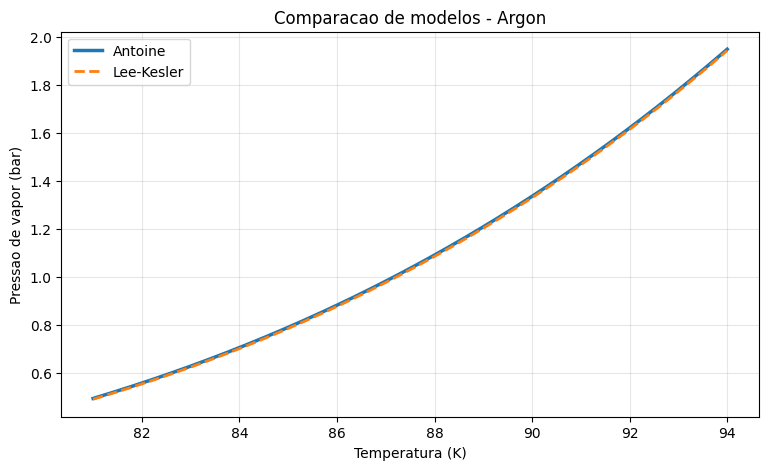

In [ ]:
# COMPARA COM O COMPOSTO DEFINIDO NO INCIO 
import numpy as np
import matplotlib.pyplot as plt
from chemicals.vapor_pressure import Lee_Kesler
from chemicals.identifiers import CAS_from_any
from chemicals.critical import Tc, Pc
from chemicals.acentric import omega

def comparar_modelos(composto, biblioteca):
    Tmin, Tmax = biblioteca.loc[composto, ["Tmin", "Tmax"]]
    T_K = np.linspace(float(Tmin), float(Tmax), 200)

    cas = CAS_from_any(composto)
    tc, pc, w = Tc(cas), Pc(cas), omega(cas)
    P_lk_bar = np.array([Lee_Kesler(float(T), tc, pc, w) for T in T_K]) / 1e5
    P_riedel_bar = np.array([psat_riedel(float(T), tc, pc) for T in T_K]) / 1e5
    P_wagner_bar = np.array([psat_wagner(float(T), tc, pc) for T in T_K]) / 1e5

    print("T range:", T_K.min(), T_K.max())
    print("Lee-Kesler bar:", np.nanmin(P_lk_bar), np.nanmax(P_lk_bar))
    print("Riedel bar:", np.nanmin(P_riedel_bar), np.nanmax(P_riedel_bar))
    print("Wagner bar:", np.nanmin(P_wagner_bar), np.nanmax(P_wagner_bar))


    plt.figure(figsize=(9,5))
    plt.plot(T_K, P_lk_bar, "--", label="Lee-Kesler", lw=2)
    plt.plot(T_K, P_riedel_bar, "-.", label="Riedel", lw=2)
    plt.plot(T_K, P_wagner_bar, ":", label="Wagner", lw=2)
    plt.xlabel("Temperatura (K)")
    plt.ylabel("Pressao de vapor (bar)")
    plt.title(f"Comparacao de modelos - {composto}")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

comparar_modelos("Argon", biblioteca)
